In [31]:
from datetime import datetime
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary
import matplotlib.pyplot as plt

#### Loading the Data

In [32]:
training_data = datasets.MNIST(
    root="../../data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.MNIST(
    root="../../data",
    train=False,
    download=True,
    transform=ToTensor()
)
print(training_data)
print(test_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../../data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: ../../data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [33]:
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)

In [34]:
data_train, labels_train = next(iter(train_dataloader))
print(f"Feature batch shape: {data_train.shape}")
print(f"Labels batch shape: {labels_train.shape}")

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


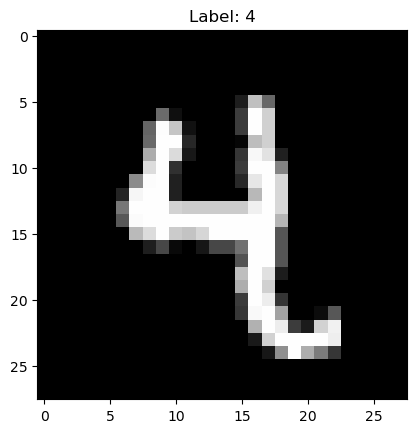

In [35]:
img = data_train[0].squeeze()
label = labels_train[0]
plt.imshow(img, cmap="gray")
plt.title(f"Label: {label}")
plt.show()

In [36]:
img.min(), img.max()

(tensor(0.), tensor(1.))

#### Multinomial Logistic Regression


##### Model

In [37]:
class LogisticRegression(torch.nn.Module):
    
    def __init__(self):
        super(LogisticRegression, self).__init__()
        self.flatten = torch.nn.Flatten()
        self.linear  = torch.nn.Linear(28*28,10)
    
    def forward(self, x):
        z = self.linear(self.flatten(x))
        return z


In [38]:
model = LogisticRegression()
print(model)

LogisticRegression(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


In [39]:
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                   [-1, 10]           7,850
Total params: 7,850
Trainable params: 7,850
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.03
Estimated Total Size (MB): 0.04
----------------------------------------------------------------


##### Cost

In [40]:
cost_ce = torch.nn.CrossEntropyLoss()

##### Training

Overfitting test based on a single training batch.

In [11]:
nepochs = 50
learning_rate = 0.2

cost_hist = []
cost_hist_test = []
acc_hist = []
acc_hist_test = []

model = LogisticRegression()
cost_ce = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Xtrain, Ytrain = next(iter(DataLoader(training_data, batch_size=64, shuffle=True)))
Xtest, Ytest = next(iter(DataLoader(test_data, batch_size=10000, shuffle=True)))

for epoch in range(nepochs):
    pred = model(Xtrain)
    loss = cost_ce(pred, Ytrain)
    cost = loss.item()
    acc = (pred.argmax(dim=1) == Ytrain).type(torch.float).mean().item()
    # gradient, parameter update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        pred = model(Xtest)
        cost_test = cost_ce(pred, Ytest).item()
        acc_test = (pred.argmax(dim=1) == Ytest).type(torch.float).mean().item()
    print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, acc, cost_test, acc_test))
    cost_hist.append(cost)
    cost_hist_test.append(cost_test)
    acc_hist.append(acc)
    acc_hist_test.append(acc_test)


Epoch 0: 2.281963, 0.062500, 2.162010, 0.186200
Epoch 1: 1.864275, 0.359375, 1.998625, 0.368800
Epoch 2: 1.592459, 0.687500, 1.871075, 0.443700
Epoch 3: 1.380255, 0.843750, 1.760289, 0.511400
Epoch 4: 1.210690, 0.921875, 1.668896, 0.550600
Epoch 5: 1.072680, 0.921875, 1.591334, 0.577700
Epoch 6: 0.958671, 0.937500, 1.525322, 0.594300
Epoch 7: 0.863335, 0.968750, 1.468671, 0.604200
Epoch 8: 0.782780, 0.968750, 1.419752, 0.613500
Epoch 9: 0.714090, 1.000000, 1.377291, 0.621700
Epoch 10: 0.655038, 1.000000, 1.340272, 0.628300
Epoch 11: 0.603891, 1.000000, 1.307870, 0.633700
Epoch 12: 0.559287, 1.000000, 1.279402, 0.638200
Epoch 13: 0.520140, 1.000000, 1.254293, 0.642600
Epoch 14: 0.485573, 1.000000, 1.232056, 0.646700
Epoch 15: 0.454878, 1.000000, 1.212279, 0.650500
Epoch 16: 0.427475, 1.000000, 1.194617, 0.653200
Epoch 17: 0.402889, 1.000000, 1.178775, 0.655900
Epoch 18: 0.380729, 1.000000, 1.164506, 0.658400
Epoch 19: 0.360669, 1.000000, 1.151603, 0.660700
Epoch 20: 0.342437, 1.000000, 

In [12]:
import math
def plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test):
    plt.figure(1)
    plt.plot(torch.arange(nepochs), cost_hist, "-", label='train')
    plt.plot(torch.arange(nepochs), cost_hist_test, "r-", label='test')
    mincost = max(max(cost_hist),1.0)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(0,mincost)
    plt.title("Cross-Entropy Cost")
    plt.legend()
    plt.figure(2)
    plt.plot(torch.arange(nepochs), acc_hist,"-", label='train')
    plt.plot(torch.arange(nepochs), acc_hist_test,"r-", label='test')
    minacc = min(min(acc_hist),0.8)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(minacc,1)
    plt.legend()
    plt.title("Accuracy")

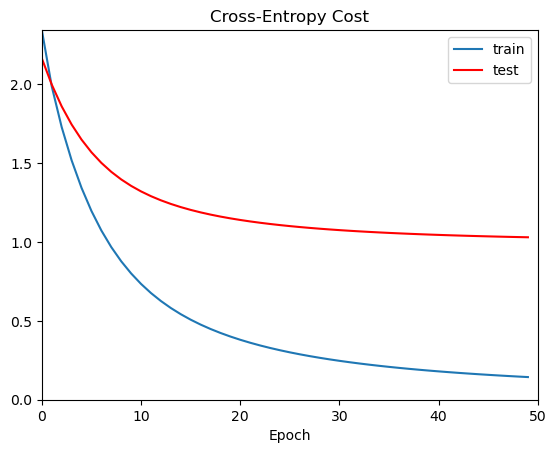

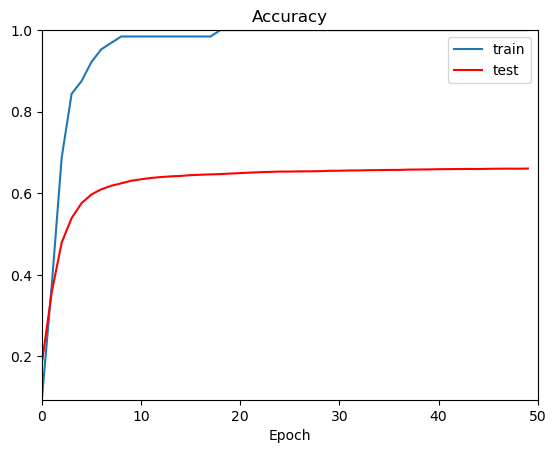

In [12]:
plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test)

In [13]:
def plot_log_regression_weights(weights):
    figure = plt.figure(figsize=(12, 4))
    cols, rows = 5, 2
    for i in range(0, cols * rows):
        img = weights[i]
        figure.add_subplot(rows, cols, i+1)
        plt.axis("off")
        plt.imshow(img, cmap="gray")
    plt.show()

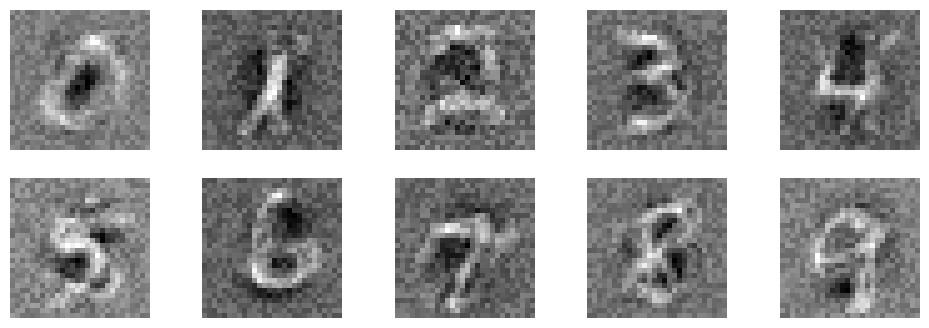

In [14]:
weights = model.linear.weight.detach().reshape(10,28,28).numpy()
plot_log_regression_weights(weights)

In [41]:
nepochs = 100
learning_rate = 0.5

cost_hist = []
cost_hist_test = []
acc_hist = []
acc_hist_test = []

model = LogisticRegression()
cost_ce = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Xtrain, Ytrain = next(iter(DataLoader(training_data, batch_size=60000, shuffle=True)))
Xtest, Ytest = next(iter(DataLoader(test_data, batch_size=10000, shuffle=True)))

for epoch in range(nepochs):
    pred = model(Xtrain)
    loss = cost_ce(pred, Ytrain)
    cost = loss.item()
    acc = (pred.argmax(dim=1) == Ytrain).type(torch.float).mean().item()
    # gradient, parameter update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        pred = model(Xtest)
        cost_test = cost_ce(pred, Ytest).item()
        acc_test = (pred.argmax(dim=1) == Ytest).type(torch.float).mean().item()
    print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, acc, cost_test, acc_test))
    cost_hist.append(cost)
    cost_hist_test.append(cost_test)
    acc_hist.append(acc)
    acc_hist_test.append(acc_test)


Epoch 0: 2.348101, 0.088900, 1.855590, 0.568200
Epoch 1: 1.862621, 0.562767, 1.516433, 0.750800
Epoch 2: 1.531765, 0.732450, 1.296822, 0.767200
Epoch 3: 1.315586, 0.760033, 1.145826, 0.808000
Epoch 4: 1.167341, 0.793700, 1.036340, 0.805600
Epoch 5: 1.059130, 0.797567, 0.954991, 0.827100
Epoch 6: 0.978642, 0.815617, 0.890251, 0.827300
Epoch 7: 0.914651, 0.817917, 0.839653, 0.838200
Epoch 8: 0.864067, 0.828650, 0.796450, 0.840700
Epoch 9: 0.821505, 0.831367, 0.761624, 0.847700
Epoch 10: 0.786362, 0.837900, 0.730815, 0.848900
Epoch 11: 0.756023, 0.840217, 0.705235, 0.853800
Epoch 12: 0.730121, 0.844617, 0.682336, 0.855500
Epoch 13: 0.707460, 0.846367, 0.662698, 0.859400
Epoch 14: 0.687599, 0.849250, 0.645002, 0.860800
Epoch 15: 0.669961, 0.851200, 0.629377, 0.863000
Epoch 16: 0.654191, 0.853383, 0.615197, 0.865300
Epoch 17: 0.639974, 0.854700, 0.602405, 0.867400
Epoch 18: 0.627073, 0.856750, 0.590708, 0.868800
Epoch 19: 0.615300, 0.858083, 0.580005, 0.870100
Epoch 20: 0.604501, 0.859700, 

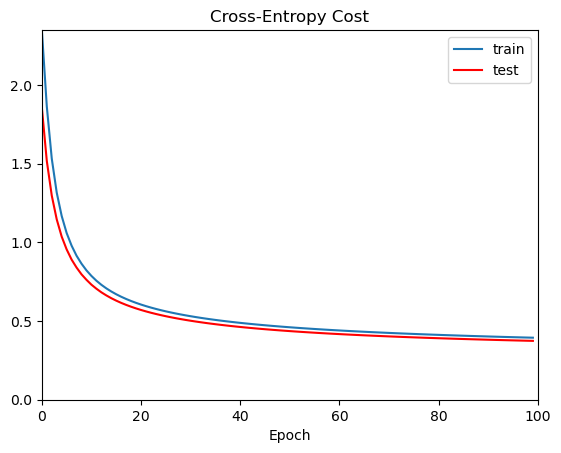

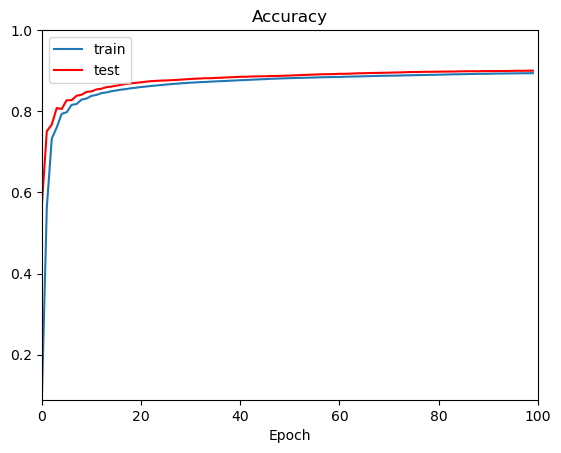

In [42]:
plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test)

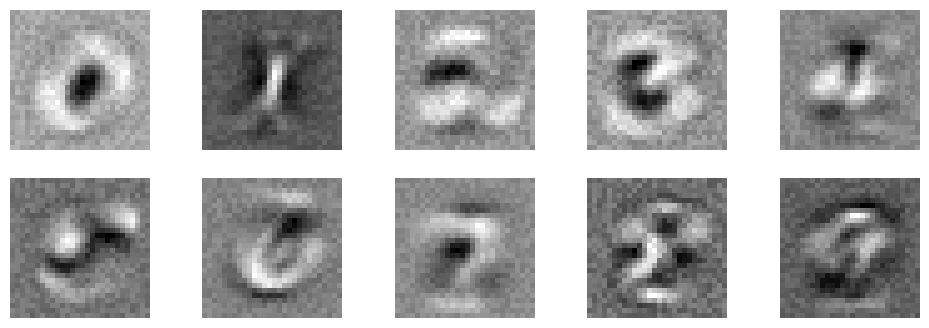

In [43]:
weights = model.linear.weight.detach().reshape(10,28,28).numpy()
plot_log_regression_weights(weights)

#### Stochastic Gradient Descent

In [24]:
nbatch = 64
nepochs = 10
learning_rate = 0.1

cost_hist = []
cost_hist_test = []
acc_hist = []
acc_hist_test = []

model = LogisticRegression()
cost_ce = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10000, shuffle=True)
size = len(training_loader.dataset)
nbatches = len(training_loader)

Xtest, Ytest = next(iter(test_loader))

for epoch in range(nepochs):
    cost, acc = 0.0, 0.0
    for batch, (X, Y) in enumerate(training_loader):
        pred = model(X)
        loss = cost_ce(pred, Y)
        cost += loss.item()
        acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

        # gradient, parameter update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    cost /= nbatches
    acc /= size
    
    with torch.no_grad():
        pred = model(Xtest)
        cost_test = cost_ce(pred, Ytest).item()
        acc_test = (pred.argmax(dim=1) == Ytest).type(torch.float).mean().item()
    print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, acc, cost_test, acc_test))
    cost_hist.append(cost)
    cost_hist_test.append(cost_test)
    acc_hist.append(acc)
    acc_hist_test.append(acc_test)


Epoch 0: 0.476442, 0.877017, 0.335182, 0.908800
Epoch 1: 0.337036, 0.905433, 0.307832, 0.913100
Epoch 2: 0.314196, 0.911933, 0.294271, 0.918700
Epoch 3: 0.302182, 0.916033, 0.288078, 0.918400
Epoch 4: 0.294234, 0.917433, 0.284242, 0.920500
Epoch 5: 0.288544, 0.919900, 0.280529, 0.922100
Epoch 6: 0.284569, 0.920550, 0.282967, 0.921200
Epoch 7: 0.281184, 0.921550, 0.275605, 0.922600
Epoch 8: 0.278067, 0.923333, 0.273367, 0.922300
Epoch 9: 0.275461, 0.923500, 0.273744, 0.922800


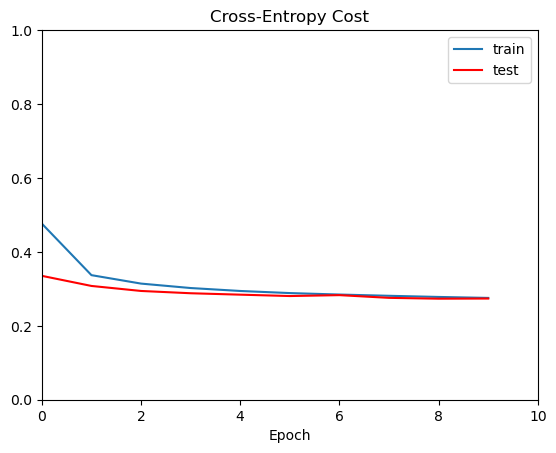

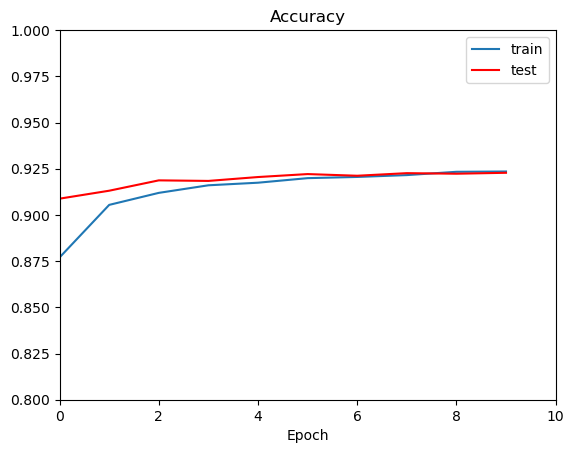

In [25]:
plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test)

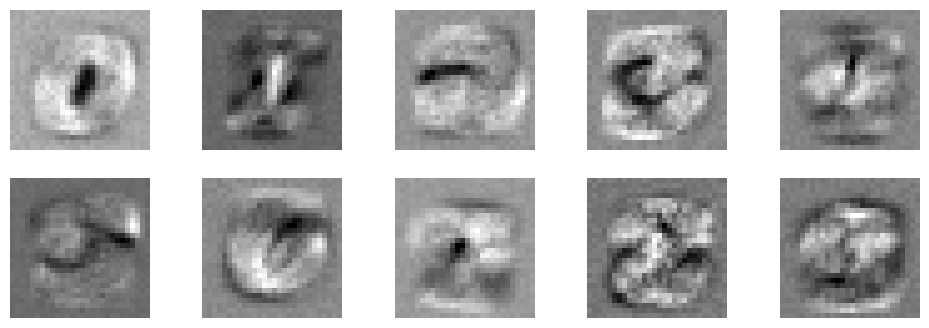

In [26]:
weights = model.linear.weight.detach().reshape(10,28,28).numpy()
plot_log_regression_weights(weights)

In [27]:
weights.min(), weights.max()

(np.float32(-0.787339), np.float32(0.9291588))

#### MLP

In [28]:
class MLP3HiddenLayers(torch.nn.Module):
    
    def __init__(self, ninput=28*28, nhidden1 = 200, nhidden2 = 100, nhidden3= 50, noutput=10):
        super(MLP3HiddenLayers, self).__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(ninput,nhidden1),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden1, nhidden2),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden2, nhidden3),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden3, noutput),
        ) 
    
    def forward(self, x):
        z = self.layers(x)
        return z


In [29]:
model = MLP3HiddenLayers(ninput=28*28, nhidden1=200, nhidden2=100, nhidden3=50, noutput=10)
print(model)

MLP3HiddenLayers(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=200, bias=True)
    (2): ReLU()
    (3): Linear(in_features=200, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=50, bias=True)
    (6): ReLU()
    (7): Linear(in_features=50, out_features=10, bias=True)
  )
)


In [30]:
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 200]         157,000
              ReLU-3                  [-1, 200]               0
            Linear-4                  [-1, 100]          20,100
              ReLU-5                  [-1, 100]               0
            Linear-6                   [-1, 50]           5,050
              ReLU-7                   [-1, 50]               0
            Linear-8                   [-1, 10]             510
Total params: 182,660
Trainable params: 182,660
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.70
Estimated Total Size (MB): 0.71
----------------------------------------------------------------


In [68]:
nbatch = 64
nepochs = 10
learning_rate = 0.01

cost_hist = []
cost_hist_test = []
acc_hist = []
acc_hist_test = []

model = MLP3HiddenLayers(ninput=28*28, nhidden1=200, nhidden2=100, nhidden3=50, noutput=10)
cost_ce = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

training_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10000, shuffle=True)
size = len(training_loader.dataset)
nbatches = len(training_loader)

Xtest, Ytest = next(iter(test_loader))

for epoch in range(nepochs):
    cost, acc = 0.0, 0.0
    for batch, (X, Y) in enumerate(training_loader):
        pred = model(X)
        loss = cost_ce(pred, Y)
        cost += loss.item()
        acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()

        # gradient, parameter update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    cost /= nbatches
    acc /= size
    
    with torch.no_grad():
        pred = model(Xtest)
        cost_test = cost_ce(pred, Ytest).item()
        acc_test = (pred.argmax(dim=1) == Ytest).type(torch.float).mean().item()
    print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, acc, cost_test, acc_test))
    cost_hist.append(cost)
    cost_hist_test.append(cost_test)
    acc_hist.append(acc)
    acc_hist_test.append(acc_test)


Epoch 0: 2.223799, 0.271483, 1.920336, 0.412800
Epoch 1: 1.129392, 0.659317, 0.676891, 0.796500
Epoch 2: 0.562425, 0.833633, 0.442409, 0.874900
Epoch 3: 0.413509, 0.882183, 0.364942, 0.895800
Epoch 4: 0.350435, 0.899150, 0.319619, 0.906500
Epoch 5: 0.311556, 0.911133, 0.282969, 0.919100
Epoch 6: 0.280471, 0.919617, 0.257778, 0.924800
Epoch 7: 0.253560, 0.927883, 0.236730, 0.928700
Epoch 8: 0.229516, 0.934717, 0.214369, 0.938700
Epoch 9: 0.208949, 0.939867, 0.194216, 0.943400


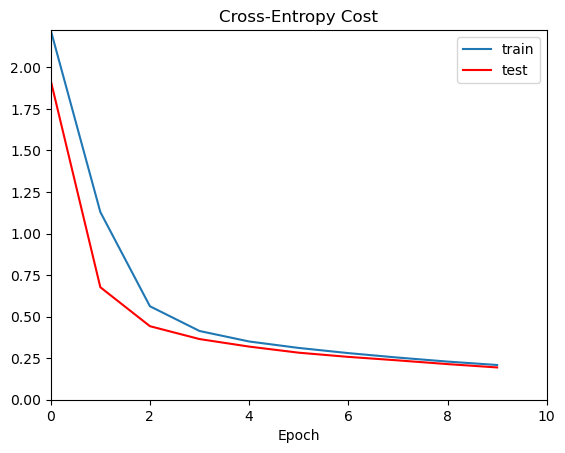

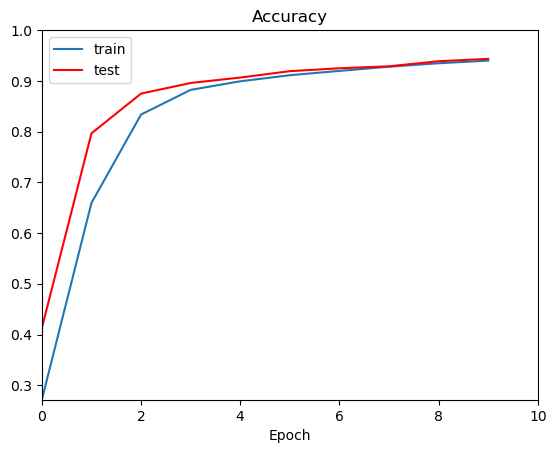

In [69]:
plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test)

#### Hyper-Parameter Tuning

Modify learning rate, batchsize, number of layers and units per layer and explore what changes these modification have on performance (train and test accuracy).

...